## Task 1: Reproducible pipelines

In [1]:
import sys, platform, os, warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, brier_score_loss,
    precision_recall_curve, make_scorer
)
from scipy import stats

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn_version)

Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1


In [2]:
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy()

target_col = "class" if "class" in df.columns else "income"
df[target_col] = df[target_col].astype(str).str.strip()
df["target"] = (df[target_col] == ">50K").astype(int)
df = df.replace(r"^\s*\?\s*$", np.nan, regex=True)

feature_cols = [c for c in df.columns if c not in [target_col, "target"]]
X = df[feature_cols]
y = df["target"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Dev:", X_dev.shape, " Test:", X_test.shape)
print("Positive rates:", round(y_train.mean(), 4), round(y_dev.mean(), 4), round(y_test.mean(), 4))

Train: (34188, 14)  Dev: (4885, 14)  Test: (9769, 14)
Positive rates: 0.2393 0.2393 0.2393


In [3]:
%%writefile feature_engineer.py
import numpy as np
import pandas as pd

class FeatureEngineer:
    @staticmethod
    def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        out["age_bucket"] = pd.cut(
            out["age"], bins=[0, 25, 35, 45, 55, 65, 120],
            labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
        ).astype(str)
        out["hours_bucket"] = pd.cut(
            out["hours-per-week"], bins=[0, 20, 35, 40, 50, 100],
            labels=["<=20", "21-35", "36-40", "41-50", "50+"]
        ).astype(str)
        out["has_capital_gain"] = (out["capital-gain"] > 0).astype(int)
        out["log_capital_gain"] = np.log1p(out["capital-gain"])
        out["higher_education"] = (out["education-num"] >= 13).astype(int)
        out["edu_hours_interaction"] = out["education-num"] * out["hours-per-week"]
        return out


Writing feature_engineer.py


In [4]:
#Reusing day3 features (imported from a real module so joblib can pickle it reliably)
from feature_engineer import FeatureEngineer

numeric_features = [
    "age", "fnlwgt", "education-num", "capital-gain", "capital-loss",
    "hours-per-week", "log_capital_gain", "edu_hours_interaction"
]
binary_features = ["has_capital_gain", "higher_education"]
categorical_features = [c for c in X.select_dtypes(exclude=[np.number]).columns.tolist()] + [
    "age_bucket", "hours_bucket"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

feature_engineer = FunctionTransformer(FeatureEngineer.add_engineered_features)
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("cat", categorical_pipeline, categorical_features),
])

def build_pipeline(estimator):
    return Pipeline([
        ("engineer", feature_engineer),
        ("preprocess", preprocessor),
        ("model", estimator),
    ])

print("Pipeline components are leak-free: feature creation + preprocessing + estimator are fitted inside each CV/search fold.")

Pipeline components are leak-free: feature creation + preprocessing + estimator are fitted inside each CV/search fold.


### **README**

To re-run the training and reproduce these results, execute all cells in this notebook sequentially. The RANDOM_STATE variable is set at the beginning to ensure deterministic outcomes for all random processes, including data splitting, hyperparameter search, and model training. The library versions used are also documented to help ensure environment consistency.

## Task 2: Controlled hyperparameter searches

In [5]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
precision_scorer = make_scorer(precision_score, zero_division=0)

search_spaces = {
    "Logistic Regression": (
        build_pipeline(LogisticRegression(
            solver="liblinear", max_iter=2000, random_state=RANDOM_STATE
        )),
        {
            "model__penalty": ["l1", "l2"],
            "model__C": np.logspace(-3, 2, 10),
        },
        10,
    ),
    "Random Forest": (
        build_pipeline(RandomForestClassifier(
            random_state=RANDOM_STATE, n_jobs=-1
        )),
        {
            "model__n_estimators": [50, 100, 150, 200],
            "model__max_depth": [8, 12, 16],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", 0.5],
        },
        5,
    ),
    "HistGradientBoosting": (
        build_pipeline(HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        )),
        {
            "model__learning_rate": [0.02, 0.06, 0.10],
            "model__max_iter": [100, 200, 300],
            "model__max_leaf_nodes": [7, 15, 31],
            "model__max_depth": [3, 5, 7],
            "model__l2_regularization": [0.0, 0.1, 1.0],
        },
        5,
    ),
}

searches = {}
search_summary = []

for name, (pipe, params, n_iter) in search_spaces.items():
    print(f"\nSearching {name} ({n_iter} candidates × 3 folds)...")
    start = time.time()
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=params,
        n_iter=n_iter,
        scoring=precision_scorer,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    elapsed = time.time() - start
    searches[name] = search
    search_summary.append({
        "model": name,
        "best_cv_precision": search.best_score_,
        "fit_time_seconds": elapsed,
        "best_params": search.best_params_,
    })
    print("Best precision:", round(search.best_score_, 4))
    print("Best params:", search.best_params_)
    print("Time:", round(elapsed, 1), "s")

search_summary_df = pd.DataFrame(search_summary)
search_summary_df[["model", "best_cv_precision", "fit_time_seconds"]]


Searching Logistic Regression (10 candidates × 3 folds)...
Best precision: 0.7668
Best params: {'model__penalty': 'l1', 'model__C': np.float64(0.001)}
Time: 89.0 s

Searching Random Forest (5 candidates × 3 folds)...
Best precision: 0.7947
Best params: {'model__n_estimators': 50, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 8}
Time: 119.7 s

Searching HistGradientBoosting (5 candidates × 3 folds)...
Best precision: 0.7856
Best params: {'model__max_leaf_nodes': 7, 'model__max_iter': 300, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__l2_regularization': 0.0}
Time: 79.4 s


,model,best_cv_precision,fit_time_seconds
0,Logistic Regression,0.766823,88.980995
1,Random Forest,0.794652,119.701608
2,HistGradientBoosting,0.785610,79.413948


In [6]:
# Compact comparison of the best search results.
search_table = pd.DataFrame([
    {"model": name, "best_precision": s.best_score_, **s.best_params_}
    for name, s in searches.items()
])
search_table

,model,best_precision,model__penalty,model__C,model__n_estimators,model__min_samples_leaf,model__max_features,model__max_depth,model__max_leaf_nodes,model__max_iter,model__learning_rate,model__l2_regularization
0,Logistic Regression,0.766823,l1,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Random Forest,0.794652,NaN,NaN,50.0,2.0,sqrt,8.0,NaN,NaN,NaN,NaN
2,HistGradientBoosting,0.785610,NaN,NaN,NaN,NaN,NaN,3.0,7.0,300.0,0.02,0.0


## Task3: Diagnose bias/variance and regularization

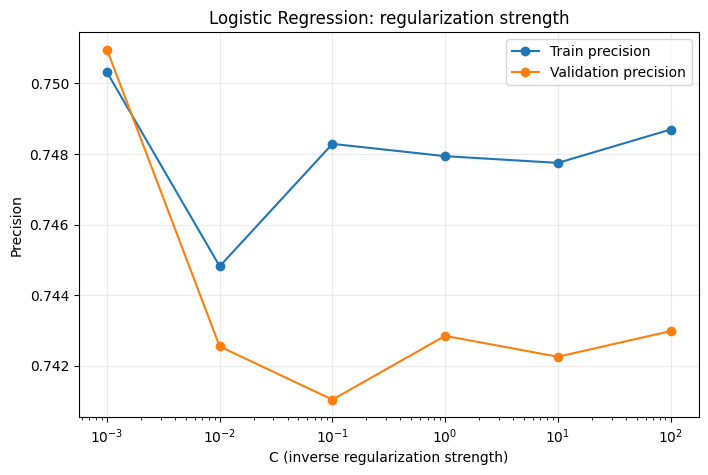

,C,train_precision,validation_precision
0,0.001,0.750316,0.750955
1,0.010,0.744817,0.742546
2,0.100,0.748285,0.741041
3,1.000,0.747937,0.742846
4,10.000,0.747746,0.742255
5,100.000,0.748692,0.742983


In [7]:
# Logistic Regression: explicit effect of C on train vs validation precision
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
lr_train_scores, lr_val_scores = [], []

for C in C_values:
    pipe = build_pipeline(LogisticRegression(
        penalty="l2", C=C, solver="liblinear", max_iter=2000,
        random_state=RANDOM_STATE
    ))
    result = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=precision_scorer, return_train_score=True, n_jobs=-1
    )
    lr_train_scores.append(result["train_score"].mean())
    lr_val_scores.append(result["test_score"].mean())

plt.figure(figsize=(8, 5))
plt.semilogx(C_values, lr_train_scores, marker="o", label="Train precision")
plt.semilogx(C_values, lr_val_scores, marker="o", label="Validation precision")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Precision")
plt.title("Logistic Regression: regularization strength")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

lr_c_table = pd.DataFrame({
    "C": C_values,
    "train_precision": lr_train_scores,
    "validation_precision": lr_val_scores,
})
lr_c_table

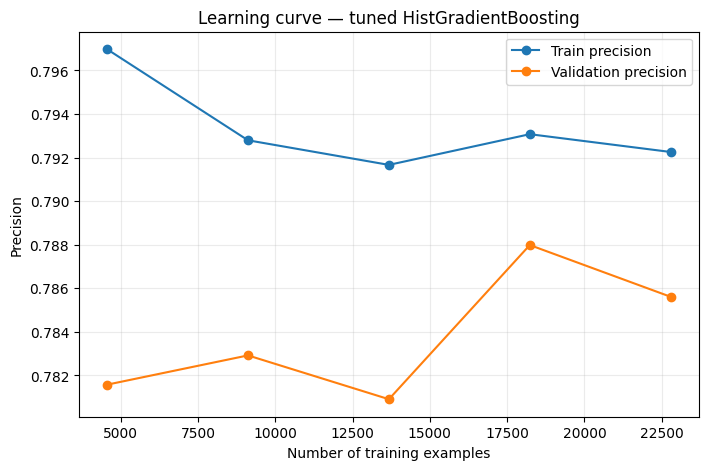

,train_size,train_precision,validation_precision
0,4558,0.796974,0.781578
1,9116,0.792795,0.782921
2,13675,0.791665,0.780910
3,18233,0.793074,0.787986
4,22792,0.792257,0.785610


In [8]:
# Learning curve for the tuned HistGradientBoosting pipeline
best_hgb = searches["HistGradientBoosting"].best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    best_hgb, X_train, y_train,
    cv=cv,
    scoring=precision_scorer,
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1,
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train precision")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation precision")
plt.xlabel("Number of training examples")
plt.ylabel("Precision")
plt.title("Learning curve — tuned HistGradientBoosting")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

learning_curve_table = pd.DataFrame({
    "train_size": train_sizes,
    "train_precision": train_scores.mean(axis=1),
    "validation_precision": val_scores.mean(axis=1),
})
learning_curve_table

In [9]:
gap = learning_curve_table["train_precision"] - learning_curve_table["validation_precision"]
max_gap = gap.max()
last_gap = gap.iloc[-1]
print(f"Maximum train-validation precision gap: {max_gap:.4f}")
print(f"Gap at full training size: {last_gap:.4f}")

if last_gap > 0.05:
    print("Interpretation: noticeable variance remains. Prefer stronger regularization / simpler tree structure or more data.")
elif learning_curve_table["validation_precision"].iloc[-1] < 0.70 and max_gap < 0.05:
    print("Interpretation: the model is comparatively biased. More expressive features/model capacity or more data may help.")
else:
    print("Interpretation: the train-validation gap is moderate; the main remaining gains are likely from tuning and threshold selection rather than simply increasing complexity.")

Maximum train-validation precision gap: 0.0154
Gap at full training size: 0.0066
Interpretation: the train-validation gap is moderate; the main remaining gains are likely from tuning and threshold selection rather than simply increasing complexity.


## Task 4: Probability calibration and threshold selection

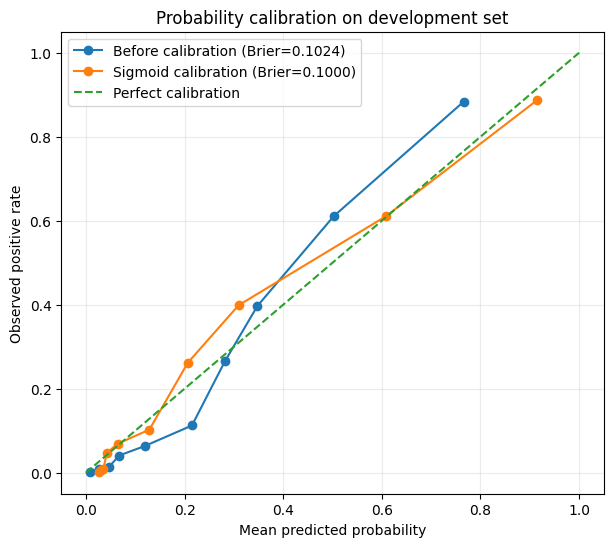

Best model: Random Forest
Brier before: 0.1024
Brier after : 0.1


In [10]:
# Calibrating using sigmoid calibration.
best_model_name = max(searches, key=lambda k: searches[k].best_score_)
best_tuned_pipeline = searches[best_model_name].best_estimator_

calibrated_model = CalibratedClassifierCV(
    estimator=best_tuned_pipeline,
    method="sigmoid",
    cv=cv,
    n_jobs=-1,
)
calibrated_model.fit(X_train, y_train)

# Comparing uncalibrated vs calibrated probabilities on the development set
uncalibrated_dev_prob = best_tuned_pipeline.predict_proba(X_dev)[:, 1]
calibrated_dev_prob = calibrated_model.predict_proba(X_dev)[:, 1]

brier_before = brier_score_loss(y_dev, uncalibrated_dev_prob)
brier_after = brier_score_loss(y_dev, calibrated_dev_prob)

prob_true_before, prob_pred_before = calibration_curve(y_dev, uncalibrated_dev_prob, n_bins=10, strategy="quantile")
prob_true_after, prob_pred_after = calibration_curve(y_dev, calibrated_dev_prob, n_bins=10, strategy="quantile")

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_before, prob_true_before, marker="o", label=f"Before calibration (Brier={brier_before:.4f})")
plt.plot(prob_pred_after, prob_true_after, marker="o", label=f"Sigmoid calibration (Brier={brier_after:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Probability calibration on development set")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Best model:", best_model_name)
print("Brier before:", round(brier_before, 4))
print("Brier after :", round(brier_after, 4))

In [11]:
# Selecting threshold using the development set
DAY3_PRECISION_REFERENCE = 0.7764

threshold_grid = np.linspace(0.10, 0.90, 161)
threshold_rows = []

for t in threshold_grid:
    pred = (calibrated_dev_prob >= t).astype(int)
    threshold_rows.append({
        "threshold": t,
        "precision": precision_score(y_dev, pred, zero_division=0),
        "recall": recall_score(y_dev, pred, zero_division=0),
        "f1": f1_score(y_dev, pred, zero_division=0),
        "accuracy": accuracy_score(y_dev, pred),
    })

threshold_df = pd.DataFrame(threshold_rows)
eligible = threshold_df[threshold_df["precision"] >= DAY3_PRECISION_REFERENCE]

if len(eligible):
    chosen_row = eligible.sort_values(["f1", "recall"], ascending=False).iloc[0]
else:
    chosen_row = threshold_df.sort_values(["precision", "f1"], ascending=False).iloc[0]

chosen_threshold = float(chosen_row["threshold"])
print("Chosen threshold:", round(chosen_threshold, 3))
print(chosen_row)

Chosen threshold: 0.425
threshold    0.425000
precision    0.780269
recall       0.595381
f1           0.675400
accuracy     0.863050
Name: 65, dtype: float64


In [12]:
# COmparing
threshold_examples = [0.30, 0.40, 0.50, chosen_threshold, 0.60, 0.70]
threshold_examples = sorted(set(round(float(x), 3) for x in threshold_examples if 0 < x < 1))

rows = []
for t in threshold_examples:
    pred = (calibrated_dev_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_dev, pred, labels=[0, 1]).ravel()
    rows.append({
        "threshold": t,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision_score(y_dev, pred, zero_division=0),
        "recall": recall_score(y_dev, pred, zero_division=0),
        "f1": f1_score(y_dev, pred, zero_division=0),
    })

threshold_comparison = pd.DataFrame(rows)
threshold_comparison

,threshold,TN,FP,FN,TP,precision,recall,f1
0,0.300,3305,411,322,847,0.673291,0.724551,0.697981
1,0.400,3483,233,455,714,0.753960,0.610778,0.674858
2,0.425,3520,196,473,696,0.780269,0.595381,0.675400
3,0.500,3552,164,525,644,0.797030,0.550898,0.651492
4,0.600,3575,141,572,597,0.808943,0.510693,0.626114
5,0.700,3590,126,611,558,0.815789,0.477331,0.602267


## Task5: Final evaluation on the untouched hold-out set

In [13]:
# Refitting on train
X_fit = pd.concat([X_train, X_dev], axis=0)
y_fit = pd.concat([y_train, y_dev], axis=0)

final_calibrated_pipeline = CalibratedClassifierCV(
    estimator=build_pipeline(
        searches[best_model_name].best_estimator_.named_steps["model"]
    ),
    method="sigmoid",
    cv=cv,
    n_jobs=-1,
)
final_calibrated_pipeline.fit(X_fit, y_fit)

test_prob = final_calibrated_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= chosen_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred, labels=[0, 1]).ravel()

final_metrics = pd.DataFrame([{
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_prob),
    "pr_auc": average_precision_score(y_test, test_prob),
    "brier": brier_score_loss(y_test, test_prob),
    "TN": tn, "FP": fp, "FN": fn, "TP": tp,
}])

final_metrics.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,TN,FP,FN,TP
0,0.8594,0.7637,0.5971,0.6702,0.9106,0.7934,0.0995,6999,432,942,1396


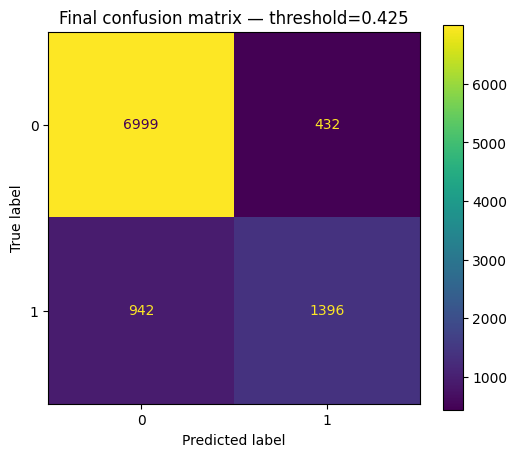

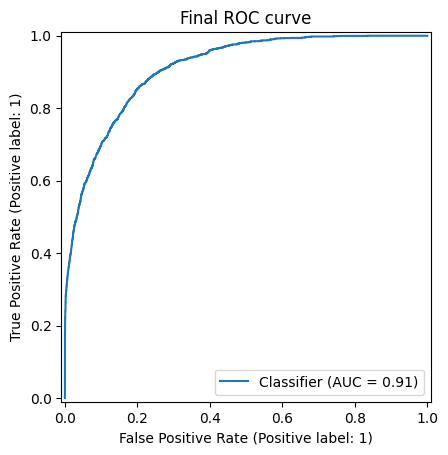

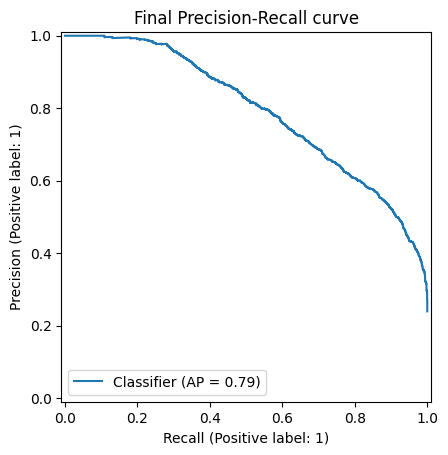

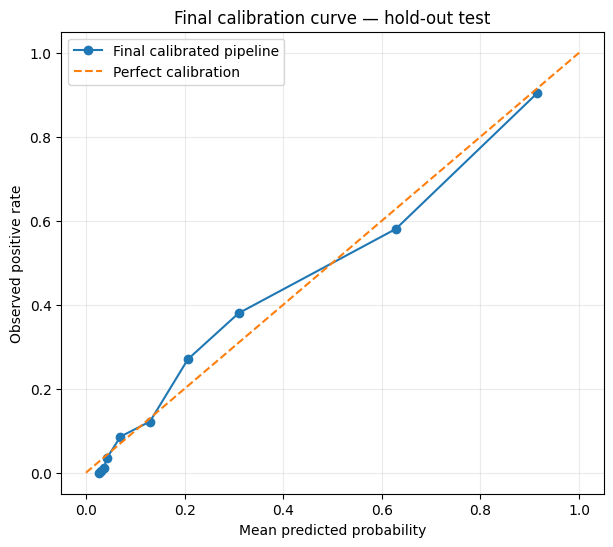

In [14]:
# Final curves and confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=ax)
ax.set_title(f"Final confusion matrix — threshold={chosen_threshold:.3f}")
plt.show()

RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title("Final ROC curve")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_prob)
plt.title("Final Precision-Recall curve")
plt.show()

prob_true_test, prob_pred_test = calibration_curve(
    y_test, test_prob, n_bins=10, strategy="quantile"
)
plt.figure(figsize=(7, 6))
plt.plot(prob_pred_test, prob_true_test, marker="o", label="Final calibrated pipeline")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Final calibration curve — hold-out test")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [15]:
# Saving pipeline
import joblib

output_dir = "/content/drive/MyDrive/Day4_Income_Model"
if not os.path.isdir("/content/drive/MyDrive"):
    output_dir = os.path.abspath("./Day4_Income_Model")
os.makedirs(output_dir, exist_ok=True)

artifact = {
    "pipeline": final_calibrated_pipeline,
    "threshold": chosen_threshold,
    "positive_label": ">50K",
    "random_state": RANDOM_STATE,
    "best_model_name": best_model_name,
    "best_search_params": searches[best_model_name].best_params_,
    "sklearn_version": sklearn_version,
}

artifact_path = os.path.join(output_dir, "day4_pipeline.joblib")
joblib.dump(artifact, artifact_path)

print("Saved:", artifact_path)

Saved: /content/Day4_Income_Model/day4_pipeline.joblib
